In [1]:
# !pip install fastparquet datashader pyproj hvplot

In [3]:
from matplotlib import pyplot as plt

# Demostración: DBSCAN

> **Cómo usar este cuaderno:** las slides de la clase (`slides/8_Clustering.pdf`) son el *mapa conceptual* — distancias, por qué escalar es obligatorio, cuándo falla cada algoritmo y si los grupos son reales. **Todo el código vive en los notebooks**: esta clase se acompaña de **dos**, `Clustering_K-means_Hierarchical.ipynb` y `Clustering_DBSCAN.ipynb` (este), en ese orden. Aquí está la referencia completa y aquí hacemos los ejercicios en clase.

Nota: Ejemplo adaptado de "Hands on Machine Learning" de Geron Aurelien.

In [4]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import numpy as np

Vamos a crear datos sintéticos no esféricos para explorar como el algoritmo DBSCAN puede ayudarnos a encontrar grupos en estos casos.

(1000, 2)


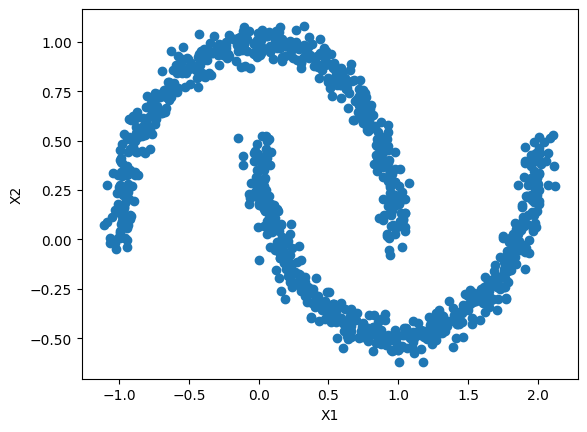

In [5]:
X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)

print(X.shape)
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('X1')
plt.ylabel('X2');

Inicializemos una instancia de DBSCAN y ajustmemos a los datos.

In [6]:
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

,eps,0.05
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


Las etiquetas encontradas están alamacenadas en el mismo atributo que en la clase KMeans. El valor de $-1$ indica que la observación fue identificada como ruido, esto es, no perteneces a ningún grupo.

In [7]:
dbscan.labels_[:10]

array([ 0,  2, -1, -1,  1,  0,  0,  0,  2,  5])

Los indices de las observaciones identificadas como "core" y sus atributos están almacenados en `core_sample_indices_` y `components_` respectivamente.

In [8]:
print(dbscan.core_sample_indices_.shape)
dbscan.core_sample_indices_[:10]

(808,)


array([ 0,  4,  5,  6,  7,  8, 10, 11, 12, 13])

In [9]:
print(dbscan.components_.shape)
dbscan.components_[:10]

(808, 2)


array([[-0.02137124,  0.40618608],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       [ 0.29248724, -0.20696309],
       [-0.02637836,  0.44766267],
       [ 1.6201408 , -0.28758856],
       [ 1.26718285, -0.40793471],
       [ 0.87418608,  0.50781041],
       [ 0.3322007 , -0.19032202],
       [ 1.952812  ,  0.22552333]])

La partición con `eps=0.05` no funciona muy bien.

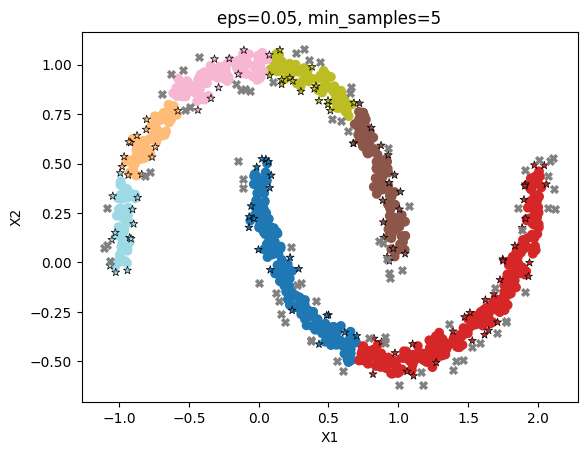

In [10]:
core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
anomalies_mask = dbscan.labels_ == -1
non_core_mask = ~(core_mask | anomalies_mask)

cores = dbscan.components_
anomalies = X[anomalies_mask]
non_cores = X[non_core_mask]

plt.scatter(cores[:, 0], cores[:, 1], c=dbscan.labels_[core_mask], cmap='tab20')
plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], cmap='tab20', marker='*', edgecolors='black', linewidth=0.5)
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='grey', marker='X', linewidth=0.4)
plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
plt.xlabel('X1')
plt.ylabel('X2');

Un valor de `eps=0.20` funciona mejor.

In [11]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit(X)

,eps,0.2
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


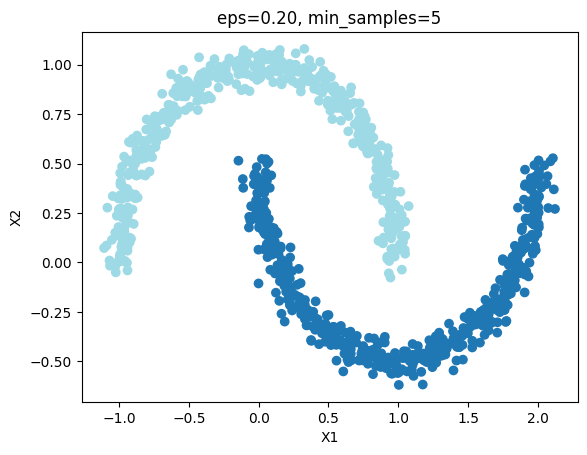

In [12]:
core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
anomalies_mask = dbscan.labels_ == -1
non_core_mask = ~(core_mask | anomalies_mask)

cores = dbscan.components_
anomalies = X[anomalies_mask]
non_cores = X[non_core_mask]

plt.scatter(cores[:, 0], cores[:, 1], c=dbscan.labels_[core_mask], cmap='tab20')
plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], cmap='tab20', marker='*', edgecolors='black', linewidth=0.5)
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='grey', marker='X', linewidth=0.4)
plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
plt.xlabel('X1')
plt.ylabel('X2');

DBSCAN no tiene un método `predict`, pero podemos usar cualquier clasificador. A modo de ejemplo, intentemos con `KNeighborsClassifier`

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

,n_neighbors,50
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

In [15]:
knn.predict_proba(X_new)

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

# Ejemplo aplicado: Taxis hotspots

In [16]:
from pathlib import Path
import urllib.request
import pandas as pd
import numpy as np
import hvplot.pandas
import datashader as ds
from sklearn.cluster import DBSCAN

from collections import Counter

En este ejemplo vamos a trabajar con una muestra de la famosa base de datos de viajes en Taxi de la ciudad de NY. Los datos completos los podemos encontrar en https://www1.nyc.gov/site/tlc/about/tlc-trip-record-data.page. Nuestra muestra consiste en los viajes realizados el mes de Enere de 2015, ya que en años posteriores se omite publicar la ubicación exacta por cuestiones de privacidad.

Nuestro objetivo es encontrar zonas de alta demanda utilizando clustering.

Primero descargamos nuestros datos y exploramos el contenido.

In [17]:
url = 'https://s3.amazonaws.com/datashader-data/nyc_taxi_wide.parq'
dfile = Path('nyc_taxi_wide.parq')

# we only download the data once
if not dfile.is_file():
    urllib.request.urlretrieve(url, dfile)

# Choose columns with location information, time and place
usecols = ['dropoff_x','dropoff_y','pickup_x','pickup_y',
           'dropoff_hour','pickup_hour','passenger_count',
           'tpep_pickup_datetime', 'tpep_dropoff_datetime']

# We need to use the fastparquet engine, pyarrow fails to import
df = pd.read_parquet(dfile, engine='fastparquet')[usecols]
df['weekday'] = df['tpep_pickup_datetime'].dt.dayofweek
df['day'] = df['tpep_pickup_datetime'].dt.day
df.head()

,dropoff_x,dropoff_y,pickup_x,pickup_y,dropoff_hour,pickup_hour,passenger_count,tpep_pickup_datetime,tpep_dropoff_datetime,weekday,day
0,-8234835.5,4975627.0,-8236963.0,4975552.5,19,19,1,2015-01-15 19:05:39,2015-01-15 19:23:42,3,15
1,-8237020.5,4976875.0,-8237826.0,4971752.5,20,20,1,2015-01-10 20:33:38,2015-01-10 20:53:28,5,10
2,-8232279.0,4986477.0,-8233561.5,4983296.5,20,20,1,2015-01-10 20:33:38,2015-01-10 20:43:41,5,10
3,-8238124.0,4971127.0,-8238654.0,4970221.0,20,20,1,2015-01-10 20:33:39,2015-01-10 20:35:31,5,10
4,-8238107.5,4974457.0,-8234433.5,4977363.0,20,20,1,2015-01-10 20:33:39,2015-01-10 20:52:58,5,10


Entre otras variables, contamos con información de ubicación para pickups y dropoff en coordenadas Web Mercator.

Vamos a darnos una idea del tamaño de nuestros datos.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11842094 entries, 0 to 11842093
Data columns (total 11 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   dropoff_x              float32       
 1   dropoff_y              float32       
 2   pickup_x               float32       
 3   pickup_y               float32       
 4   dropoff_hour           uint8         
 5   pickup_hour            uint8         
 6   passenger_count        uint8         
 7   tpep_pickup_datetime   datetime64[ns]
 8   tpep_dropoff_datetime  datetime64[ns]
 9   weekday                int32         
 10  day                    int32         
dtypes: datetime64[ns](2), float32(4), int32(2), uint8(3)
memory usage: 485.6 MB


Con casi 12 millones de observaciones, no es conveniente intentar hacer clustering con los datos completos, al menos no con los algoritmos que hemos estudiado. Aún así, es probablemente más interesante mirar si hay cambios en los patrones de viajes dependiendo del día de la semana, o la hora del día. Veamos como es la distribución de pickups por hora del día.

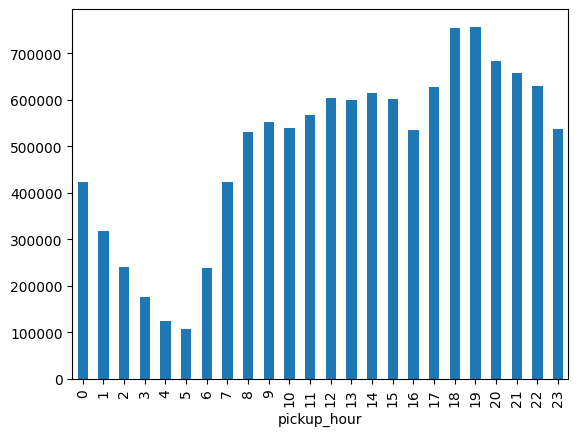

In [19]:
pickup_hour_counts = df.groupby('pickup_hour').size()
pickup_hour_counts.plot.bar();

La demanda alcanza el máximo a las 7pm, hagamos una gŕafica para distinguir diferencias para la demanda horaria e identificar zonas de alta densidad visualmente. No podemos hacer un scatter plot, dada la gran cantidad de puntos, será muy dificil distinguir patrones en el scatter plot. Utilizaremos datashader para este propósito.

In [20]:
df['pickup_hour_cat'] = df.pickup_hour.astype(str)

In [21]:
df.hvplot.points(x='pickup_x', y='pickup_y', groupby='pickup_hour', datashade=True, tiles='OSM')

BokehModel(combine_events=True, render_bundle={'docs_json': {'70772949-aefc-4199-bc4e-b5d11a6c1e2f': {'version…

Para probar nuestro agrupamiento, vamos a elegir la hora con más demanda. Pero primero hay algunos puntos finos que discutir. Las coordenadas nos las dan en Web Mercator, pero no es corrector calcular la distancia euclidiana en esa proyección. Tenemos dos opciones, proyectar a lat-long y usar la distancia geodésica (Haversine) o proyectar UTM que nos da las coordenadas en metros a partir de un punto de referencia.

La opción 1 es la más exacta, pero es calcular la distancia geodésica es más costoso que la euclidiana. Aún más, existe un bug en la implementación de HDBSCAN/DBSCAN en Scikit-learn que hace imposible usar la distancia geodésica con bases de datos grandes, (https://github.com/scikit-learn-contrib/hdbscan/issues/345).

Eso nos deja con la opción 2. Cuando proyectamos a UTM incurrimos en algunos errores de deformación, pero no son muy importantes si nuestra región es pequeña, especialmente es adecuado si todos nuestros datos se localizan dentro de la misma región UTM, como es el caso actual. Dado que el mundo se divide en una gradilla de multiples regiones UTM, necesitamos encontrar la correcta para la zona de nuestros datos. Aún tenemos que convertir primero a lat-lon para luego hacer el query de la región UTM adecuada.

In [22]:
from pyproj import Transformer

# Original projection: epsg:3857 (Web Mercator)
# Lat-lon projection: epsg:4326

transformer = Transformer.from_crs(3857, 4326, always_xy=True)

df["pickup_lat"], df["pickup_lon"] = transformer.transform(df['pickup_x'], df['pickup_y'])

In [23]:
from pyproj.aoi import AreaOfInterest
from pyproj.database import query_utm_crs_info

minx, miny, maxx, maxy = min(df['pickup_lon']), min(df['pickup_lat']), max(df['pickup_lon']), max(df['pickup_lat'])
x_center = np.mean([minx, maxx])
y_center = np.mean([miny, maxy])

utm_crs_list = query_utm_crs_info(
        datum_name="WGS 84",
        area_of_interest=AreaOfInterest(
            west_lon_degree=x_center,
            south_lat_degree=y_center,
            east_lon_degree=x_center,
            north_lat_degree=y_center,
        ),
)

print(utm_crs_list[0])
print(utm_crs_list[0].code)

CRSInfo(auth_name='EPSG', code='32737', name='WGS 84 / UTM zone 37S', type=<PJType.PROJECTED_CRS: 'PROJECTED_CRS'>, deprecated=False, area_of_use=AreaOfUse(west=36.0, south=-80.0, east=42.0, north=0.0, name='Between 36°E and 42°E, southern hemisphere between 80°S and equator, onshore and offshore. Kenya. Mozambique. Tanzania.'), projection_method_name='Transverse Mercator')
32737


In [24]:
transformer = Transformer.from_crs(3857, 32618, always_xy=True)
df["pickup_x_utm"], df["pickup_y_utm"] = transformer.transform(df['pickup_x'], df['pickup_y'])
df.head()

,dropoff_x,dropoff_y,pickup_x,pickup_y,dropoff_hour,pickup_hour,passenger_count,tpep_pickup_datetime,tpep_dropoff_datetime,weekday,day,pickup_hour_cat,pickup_lat,pickup_lon,pickup_x_utm,pickup_y_utm
0,-8234835.5,4975627.0,-8236963.0,4975552.5,19,19,1,2015-01-15 19:05:39,2015-01-15 19:23:42,3,15,19,-73.993898,40.750110,584934.173480,4.511504e+06
1,-8237020.5,4976875.0,-8237826.0,4971752.5,20,20,1,2015-01-10 20:33:38,2015-01-10 20:53:28,5,10,20,-74.001650,40.724245,584312.360513,4.508626e+06
2,-8232279.0,4986477.0,-8233561.5,4983296.5,20,20,1,2015-01-10 20:33:38,2015-01-10 20:43:41,5,10,20,-73.963341,40.802789,587444.628700,4.517382e+06
3,-8238124.0,4971127.0,-8238654.0,4970221.0,20,20,1,2015-01-10 20:33:39,2015-01-10 20:35:31,5,10,20,-74.009088,40.713817,583697.255255,4.507461e+06
4,-8238107.5,4974457.0,-8234433.5,4977363.0,20,20,1,2015-01-10 20:33:39,2015-01-10 20:52:58,5,10,20,-73.971175,40.762430,586836.413913,4.512894e+06


Estamos listos para el clustering. Vamos a filtrar nuestro dataset y pensemos un poco en los parámetros de adecuados para DBSCAN. Recordemos que DBSCAN requiere que elijamos dos parámetros, `minpts` y `eps`, el número de vecinos y el radio a considerar al momento de determinar los core points. No es trivial elegir correctamente estos parámetros, pero podemos estimar la densidad que nos interesa usando información de nuestros dataset.

Casi todos los puntos se localican en Manhattan, que tiene un área de aproximadamente 60 km². La longitud promedio de una manzana es de aproximadamente 80 metros. 

In [25]:
hr = 18
df_hr = df[(df.pickup_hour == 18) & (df.weekday < 5)]
mean_density = len(df_hr)/60e6
print(mean_density)
expected_rides_per_block = mean_density*80**2
expected_rides_per_block

0.008961833333333334


57.35573333333333

Queremos identificar regiones de alta densidad. Digamos, 10 veces más que la densidad promedio, aprox 1. Fijando un epsilon de cuarto de manzana, 2m, esto se traduce en minpts de 

In [26]:
target_density = 1
eps = 2
area_eps = np.pi*eps**2
minpts = int(area_eps*target_density)
minpts

12

El algoritmo HDBSCAN es un generalización de DBSCAN que permite extraer clusters de densidad variable en un mismo dataset. Aquí no lo usaremos así, si no que aprovecharemos que podemos ejecutarlo una vez y nos permite obtener la soluciones de DBSCAN para minpts fijo y eps variable. El parametro min_cluster_size es irrelevante para nuestra aplicación.

In [27]:
points = df_hr[['pickup_x_utm', 'pickup_y_utm']]
clusterer = DBSCAN(eps=eps, min_samples=minpts)
clusterer.fit(points.values)

,eps,2
,min_samples,12
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [28]:
labels = clusterer.labels_
cluster_sizes = Counter(labels)
len(cluster_sizes)

156

In [29]:
df_hr.assign(labels=labels.astype(str)).query('labels!="-1"').hvplot.points(x='pickup_x', y='pickup_y', by='labels', datashade=False, tiles='OSM')

:Overlay
   .Tiles.I     :Tiles   [x,y]
   .NdOverlay.I :NdOverlay   [labels]
      :Points   [pickup_x,pickup_y]